# Station-MAE — Test Results

Five analyses, all computed from the saved `predictions.pt` dumps (full sliding test set):

Model families that appear here (all share dataset, splits, per-station
normalisation, PFA exclusion, Huber loss and the 13-lead grid — so every
comparison below is apples-to-apples):

| run prefix        | design | forecast produced by |
|-------------------|---|---|
| `v27 ... v29`     | Δ-query cross-attention decoder + station masking | 2-layer decoder |
| `lstm-baseline-*` | per-station recurrence, spatially blind | LSTM + multi-horizon head |

1. **Effect of masking** — mr0.50 vs mr0.00 on the *masked* stations
2. **Model comparison vs persistence** — per-variable, per lead-time (mr0.50)
3. **Terrain** — valley vs mountainous stations
4. **Per-station × variable × season** — which stations work and which don't

Errors are in **physical units** (per-station training σ). Files are ~1.6 GB each, so
§0 aggregates one run at a time and keeps only small summary tables — the raw arrays
are never all in memory at once.

**5. Predicted uncertainty** — for NLL models only (v9). The decoder emits a per-(horizon, station, variable) log σ² alongside the mean, so we can ask whether the model *knows* when it is wrong.


In [35]:
# ── Config ───────────────────────────────────────────────────────────────────
import os, sys, glob, datetime
import numpy as np, pandas as pd, matplotlib.pyplot as plt
# ── Project bootstrap ────────────────────────────────────────────────────────
# This notebook lives in notebooks/ but reads checkpoints/, test_results/ and
# report/ from the project root, and imports data/engine/model from src/.
# Re-running this cell is safe (it only climbs out of notebooks/ once).
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
PROJ = os.getcwd()
if os.path.join(PROJ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(PROJ, "src"))

RESULTS_ROOT = "test_results"
EXCLUDE      = ["PFA"]
CHUNK        = 2000          # windows processed at a time (memory control)

# Terrain split (§3) — a station is "mountain" if it is high OR steep.
ALT_THRESH   = 1000.0        # m
SLOPE_THRESH = 7.0           # SLOPE_2000M_SIGRATIO1

# Metric shown in the PLOTS below. Tables always report MAE, MSE and RMSE.
#   MAE  = mean |error|      — robust, same units as the variable
#   MSE  = mean error²       — SQUARED units; penalises large errors quadratically
#   RMSE = sqrt(MSE)         — back in the variable's own units
# MSE/RMSE are the ones to quote when large errors matter more than typical
# ones; MAE is the one to quote when they do not. They can rank models
# differently, which is itself worth reporting.
METRIC = "MAE"          # ← "MAE" | "MSE" | "RMSE"

# ── Station x variable exclusions ────────────────────────────────────────────
# Instrument-level exclusions for the results section. Applied ONCE, inside
# aggregate(), by ANDing into the observation-validity mask — so every table and
# plot below (model, persistence, climatology, per-station, seasonal) inherits
# them and none of them can silently disagree with another.
#   "all"  drops the station entirely
#   [list] drops only those variables at that station
DROP_SV = {
    "GES": ["pressure"],
    "PFA": "all",                       # already dropped by EXCLUDE, asserted below
    "LAE": ["wind_u", "wind_v"],        # "wind" = both components
}

# ── Climatology baseline ─────────────────────────────────────────────────────
# clim(T) = the observation at the SAME station and variable exactly 24 h before
# the target time. Forecasting 2023-09-22 14:00…20:00 uses 2023-09-21 14:00…20:00.
# On the 10-min grid that is a fixed 144-step lag. Unlike persistence it carries
# the diurnal cycle, so it is the harder baseline at long lead times: persistence
# decays as the forecast walks away from t0, climatology does not.
CLIM_LAG_STEPS = 144                    # 24 h / 10 min

VARS   = ["temperature", "pressure", "humidity", "wind_u", "wind_v"]
UNITS  = {"temperature":"°C","pressure":"hPa","humidity":"%","wind_u":"m/s","wind_v":"m/s"}
SEASONS = ["DJF","MAM","JJA","SON"]
# One colour per run family. Unknown runs fall back to the cycle below, so a
# new dump never breaks a plot — use COLOR(run) rather than COLORS[run].
COLORS = {
    # transformer line (delta-query decoder, MAE station masking)
    "v15": "#D9663D",          # patch-3 tokens, no residual
    "v17": "#E08A5C",          # token rebalance
    "v19": "#C4502A",          # v17 + MLP value embedding
    "v20": "#2E7D8C",          # + persistence residual head, station_state
    "v27": "#1F5F6B",          # direct head, no masking, no decoder
    "v30-nll":  "#E1A730",     # v27 + heteroscedastic Gaussian NLL head
    "v31":      "#D9663D",     # v27 trained at mask_ratio 0
    "v32-blind":"#5FAF5F",     # no encoder spatial attn + station-local decoder
    # canonical MAE (future in the token grid)
    "simple-mae-v2": "#3F7D3F",
    # encoder-only masked transformer (in-place corruption, pooled readout)
    "masked-tf-v1":  "#7B5EA7",
    # baselines
    "lstm-baseline-v1": "#6A4C93", "lstm-baseline-v2": "#9B7FC0",
    "persistence": "#888888", "climatology": "#CCCCCC",
}
_CYCLE = ["#D9663D", "#2E7D8C", "#5FAF5F", "#7B5EA7", "#C9A227", "#B5651D"]
def COLOR(run):
    """Stable colour for any run name, known or not.

    NOTE: this used to read `return COLOR(run)` inside the `if`, which recursed
    until RecursionError for every KNOWN run — i.e. it failed on exactly the
    runs it had a colour for. Fixed to index the dict.
    """
    if run in COLORS:
        return COLORS[run]
    return _CYCLE[abs(hash(run)) % len(_CYCLE)]

_CAND = ["/home/renku/work/PeakWeatherDataset",
         os.path.expanduser("~/Documents/ETH/_DAS Project/PeakWeatherDataset"),
         os.path.expanduser("~/PeakWeatherDataset"), "PeakWeatherDataset"]
DATA_ROOT = next((p for p in _CAND if os.path.isdir(p)), _CAND[-1])
plt.rcParams.update({"figure.dpi":110, "font.size":10})

# discover available runs: {run: {mask_ratio: path}}
RUNS = {}
for p in sorted(glob.glob(os.path.join(RESULTS_ROOT, "*", "best_mr*", "predictions.pt"))):
    run = p.split(os.sep)[-3]; mr = p.split(os.sep)[-2].replace("best_", "")
    RUNS.setdefault(run, {})[mr] = p
for r, d in RUNS.items():
    print(f"{r:20s} {sorted(d)}")

lstm-baseline-v1     ['mr0.00']
v27                  ['mr0.00', 'mr0.50']
v30-nll              ['mr0.00', 'mr0.50']
v31                  ['mr0.00']
v32-blind            ['mr0.00']


In [36]:
# ── Station metadata: physical scale + terrain class ─────────────────────────
from data.dataset import load_peakweather, StationMAEDataset, compute_obs_stats
ds   = load_peakweather(root=DATA_ROOT)
keep = StationMAEDataset._resolve_keep_indices(ds, EXCLUDE)
STN  = [ds.stations_table.index[i] for i in keep]          # station ids, prediction order
N    = len(STN)

# per-(station, variable) training σ → physical units
_st   = compute_obs_stats(ds, train_years=None, per_station=True)
STD   = np.clip(_st["std"].numpy()[keep][:, :5], 1e-6, None)          # (N, 5)
MEAN  = _st["mean"].numpy()[keep][:, :5]                              # (N, 5)

# terrain
_t     = ds.stations_table.loc[STN]
alt    = _t["station_height"].astype(float).values
slope  = _t["SLOPE_2000M_SIGRATIO1"].astype(float).values
IS_MTN = (alt >= ALT_THRESH) | (slope >= SLOPE_THRESH)                # (N,) bool

# Guard: the station axis of the dumps must match this station list exactly.
# (load_peakweather drops stations lacking the requested parameters, so the raw
#  stations table is larger than the modelled network — never index it directly.)
import torch as _t
_probe = _t.load(next(iter(next(iter(RUNS.values())).values())),
                 map_location="cpu", weights_only=False)["preds"].shape[2]
assert _probe == N, (f"station mismatch: predictions have {_probe} stations but the "
                     f"dataset resolved {N}. Check EXCLUDE={EXCLUDE}.")
del _probe

print(f"stations: {N}   mountain: {IS_MTN.sum()}   valley: {(~IS_MTN).sum()}")
print(f"  mountain: alt {alt[IS_MTN].mean():.0f} m, slope {slope[IS_MTN].mean():.1f}")
print(f"  valley  : alt {alt[~IS_MTN].mean():.0f} m, slope {slope[~IS_MTN].mean():.1f}")

# ── Station x variable exclusion mask ───────────────────────────────────────
# KEEP is (N, 5) and is ANDed into the validity mask in aggregate(). Unknown
# station or variable names raise instead of silently dropping nothing — a
# typo'd abbreviation is otherwise indistinguishable from a clean run.
KEEP, _rep = np.ones((N, len(VARS)), bool), []
for _stn, _spec in DROP_SV.items():
    if _stn not in STN:
        if _stn in EXCLUDE:
            _rep.append(f"  {_stn:<4}  already excluded from the network by EXCLUDE")
            continue
        raise KeyError(f"DROP_SV names station {_stn!r}, which is neither in the "
                       f"modelled network nor in EXCLUDE={EXCLUDE}. Check the "
                       f"abbreviation against ds.stations_table.index.")
    _vs = list(VARS) if _spec == "all" else list(_spec)
    _bad = [v for v in _vs if v not in VARS]
    if _bad:
        raise KeyError(f"DROP_SV[{_stn!r}] names unknown variables {_bad}; VARS={VARS}")
    _si = STN.index(_stn)
    for _v in _vs:
        KEEP[_si, VARS.index(_v)] = False
    _rep.append(f"  {_stn:<4}  station index {_si:3d}   dropped: {', '.join(_vs)}")

print("\nstation x variable exclusions")
print("\n".join(_rep))
print(f"  cells kept: {KEEP.sum()}/{KEEP.size}"
      f"  ({KEEP.size - KEEP.sum()} station-variable pairs dropped)")

stations: 155   mountain: 74   valley: 81
  mountain: alt 1620 m, slope 8.5
  valley  : alt 540 m, slope 2.0

station x variable exclusions
  GES   station index  59   dropped: pressure
  PFA   already excluded from the network by EXCLUDE
  LAE   station index  83   dropped: wind_u, wind_v
  cells kept: 772/775  (3 station-variable pairs dropped)


### Climatology lookup

`clim(T) = obs(T - 24 h)` at the same station and variable. The dumps do not
contain the previous day, so this reads the raw parquet observations and indexes
them by absolute time. The verification cell below is the load-bearing part: it
denormalises the dump's own targets and checks them against the parquet values at
the same timestamps. If the station ordering, the hour-to-row mapping or the
normalisation statistics are wrong, climatology would be silently misaligned and
every number in section 2 would be wrong — so that check raises rather than warns.

In [37]:
# ── Climatology lookup: obs(T - 24 h) ───────────────────────────────────────
import pandas as pd
from data.dataset import build_observations, TEST_YEARS

_obs, _msk, _ts = build_observations(ds)          # (T, N_all, 6) PHYSICAL, raw
_ts = pd.DatetimeIndex(_ts)

# Restrict to the test years plus CLIM_LAG_STEPS rows of run-up, so the first
# test timestamp still has a predecessor 24 h earlier. Full history would be
# ~1.5 GB; this slice is ~0.4 GB.
_sel  = np.where(_ts.year.isin(TEST_YEARS))[0]
_lo   = max(0, int(_sel[0]) - CLIM_LAG_STEPS)
_hi   = int(_sel[-1]) + 1
OBS_P = _obs[_lo:_hi][:, keep, :5].numpy()                 # (Tc, N, 5) physical
OBS_M = _msk[_lo:_hi][:, keep, :5].numpy() > 0.5           # (Tc, N, 5) bool
TS_C  = _ts[_lo:_hi]
del _obs, _msk, _sel

# A fixed 144-step lag is 24 h only on a strictly regular grid. Verify, do not assume.
_step = np.unique(np.diff(TS_C.asi8))
assert len(_step) == 1 and _step[0] == 10 * 60 * 10**9, \
    f"observation grid is not regular 10-min: found steps {_step}"
H0   = (TS_C[0] - pd.Timestamp("1970-01-01", tz="UTC")) / pd.Timedelta("1h")
NT_C = len(TS_C)

# Both baselines are DIFFERENCES OF RAW OBSERVATIONS, so they are computed
# directly in physical units. Nothing here is normalised: no MEAN, no STD, no
# round trip. (The model error still uses |p - t| * STD, because the model's
# prediction only exists in normalised space — but MEAN cancels in that
# difference, so it never appears either.)

def base_at(th):
    """
    th (c, K) hours since epoch -> raw physical sources for both baselines.

        truth       obs(t)          the verification target
        pers        obs(t0)         last observation, carried forward
        clim        obs(t - 24 h)   same clock time yesterday

    Returned with each source's own availability mask, since a baseline is only
    defined where ITS source exists.
    """
    ti = np.rint((th - H0) * 6.0).astype(np.int64)     # 6 rows per hour
    pi = ti[:, 0:1]                                    # delta_steps[:,0]==0 -> t0
    ci = ti - CLIM_LAG_STEPS
    okc = (ci >= 0) & (ci < NT_C)
    cg  = np.clip(ci, 0, NT_C - 1)
    return (OBS_P[ti],                                 # truth   (c,K,N,5)
            OBS_P[pi], OBS_M[pi],                      # persistence (broadcasts over K)
            OBS_P[cg], OBS_M[cg] & okc[:, :, None, None])   # climatology

print(f"climatology window: {TS_C[0]}  ..  {TS_C[-1]}   ({NT_C:,} rows)")
print(f"  lag {CLIM_LAG_STEPS} steps = {CLIM_LAG_STEPS*10/60:.0f} h")
print(f"  observation coverage in window: {OBS_M.mean()*100:.1f}%")

climatology window: 2022-12-31 00:00:00+00:00  ..  2024-12-31 23:50:00+00:00   (105,408 rows)
  lag 144 steps = 24 h
  observation coverage in window: 94.6%


In [38]:
# ── Verify station order, time index and normalisation against a real dump ──
import torch
_p  = next(iter(next(iter(RUNS.values())).values()))
_d  = torch.load(_p, map_location="cpu", weights_only=False)
_th = _d["target_hours"][:200].numpy()
_tt = _d["targets"][:200, :, :, :5].numpy()
_tm = _d["masks"][:200, :, :, :5].numpy() > 0.5
_ti = np.rint((_th - H0) * 6.0).astype(np.int64)
assert _ti.min() >= 0 and _ti.max() < NT_C, \
    "dump target times fall outside the climatology slice — TEST_YEARS mismatch?"

_raw  = OBS_P[_ti]                                    # physical, from parquet
_dump = _tt * STD[None, None] + MEAN[None, None]      # physical, from the dump
_ok   = _tm & OBS_M[_ti]
_dev  = np.abs(_raw - _dump)[_ok]
print(f"checked {_ok.sum():,} target values from {os.path.relpath(_p)}")
print(f"  max |parquet - dump| = {_dev.max():.3e}    median = {np.median(_dev):.3e}")
assert _dev.max() < 1e-2, (
    f"targets in the dump do not match the parquet observations at the same "
    f"timestamps (max deviation {_dev.max():.3e}). One of: station ordering, the "
    f"hour->row mapping, or the normalisation statistics is wrong. Climatology "
    f"would be misaligned and section 2 invalid. STOP HERE.")
print("  OK — station order, time index and normalisation all agree.")
del _d, _tt, _tm, _raw, _dump, _ok, _dev

checked 1,905,800 target values from test_results/lstm-baseline-v1/best_mr0.00/predictions.pt
  max |parquet - dump| = 9.537e-06    median = 0.000e+00
  OK — station order, time index and normalisation all agree.


## 0. Aggregation pass

Each dump is streamed in chunks; we accumulate absolute-error sums and counts at the
granularity every later section needs, then release the arrays. **Persistence** is
derived from the same file (`targets[:, 0]` = the last observation carried forward),
so it sits on identical windows and masks.

In [39]:
# ── Stream each run and accumulate summary tables ────────────────────────────
import torch

def _season_idx(hours):                     # hours since epoch → 0..3
    ep = datetime.datetime(1970,1,1)
    m  = np.array([(ep + datetime.timedelta(hours=float(h))).month for h in hours.ravel()])
    s  = np.select([np.isin(m,[12,1,2]), np.isin(m,[3,4,5]), np.isin(m,[6,7,8])], [0,1,2], 3)
    return s.reshape(hours.shape)

def aggregate(path):
    """Return dicts of summed |err| and counts at several granularities."""
    d = torch.load(path, map_location="cpu", weights_only=False)
    P, T, M = d["preds"], d["targets"], d["masks"]
    TH, MI  = d["target_hours"], d.get("masked_idx")
    Mw, K   = P.shape[0], P.shape[1]
    # Sigma|e| under each key, and Sigma e^2 under key + "_sq", so MAE, MSE and
    # RMSE all come from one streaming pass over the dump.
    #   _p = persistence  (carry y(t0) forward)
    #   _c = climatology  (the observation 24 h before the target)
    #   _m = masked stations only
    _shapes = {
        "kv":(K,len(VARS)), "kv_p":(K,len(VARS)), "kv_c":(K,len(VARS)),
        "kv_m":(K,len(VARS)), "kv_m_p":(K,len(VARS)), "kv_m_c":(K,len(VARS)),
        "sv":(N,len(VARS)), "svs":(N,len(VARS),4),
    }
    A = {k: np.zeros(sh) for k, sh in _shapes.items()}
    A.update({k + "_sq": np.zeros(sh) for k, sh in _shapes.items()})
    # Every key gets its OWN counter. Persistence and climatology are valid on
    # strict SUBSETS of the model's valid set (they additionally need y(t0), or
    # the observation 24 h earlier, to exist), so dividing their error sums by
    # the model's count understates their error and flatters the model's skill.
    C = {k: np.zeros(sh) for k, sh in _shapes.items()}

    for a in range(0, Mw, CHUNK):
        b   = min(a+CHUNK, Mw)
        p   = P[a:b].numpy(); t = T[a:b,:,:,:5].numpy()
        # KEEP applies the station x variable exclusions once, here, so every
        # downstream number inherits them.
        m   = (M[a:b,:,:,:5].numpy() > 0.5) & KEEP[None,None,:,:]
        err = np.abs(p - t) * STD[None,None,:,:]                     # (c,K,N,V) physical

        # Baselines, straight off the raw observations — no normalisation.
        th  = TH[a:b].numpy()
        truth, pers, mper, clim, mcl = base_at(th)
        errp = np.abs(pers - truth)                                  # physical, degC/hPa/%/(m/s)
        errc = np.abs(clim - truth)
        mp   = m & mper                                              # valid at Δ0 AND horizon
        mc   = m & mcl                                               # valid now AND 24 h ago
        sea  = _season_idx(th)                                       # (c,K)

        e2, ep2, ec2 = err**2, errp**2, errc**2
        A["kv"]      += (err *m ).sum(axis=(0,2));  C["kv"]   += m.sum(axis=(0,2))
        A["kv_sq"]   += (e2  *m ).sum(axis=(0,2))
        A["kv_p"]    += (errp*mp).sum(axis=(0,2));  C["kv_p"] += mp.sum(axis=(0,2))
        A["kv_p_sq"] += (ep2 *mp).sum(axis=(0,2))
        A["kv_c"]    += (errc*mc).sum(axis=(0,2));  C["kv_c"] += mc.sum(axis=(0,2))
        A["kv_c_sq"] += (ec2 *mc).sum(axis=(0,2))

        if MI is not None and MI.shape[1] > 0:                       # masked-station subset
            mi  = MI[a:b].numpy()
            sel = np.zeros((b-a, N), bool)
            np.put_along_axis(sel, mi, True, axis=1)
            sm  = m  & sel[:,None,:,None]
            smp = mp & sel[:,None,:,None]
            smc = mc & sel[:,None,:,None]
            A["kv_m"]      += (err *sm ).sum(axis=(0,2)); C["kv_m"]   += sm.sum(axis=(0,2))
            A["kv_m_sq"]   += (e2  *sm ).sum(axis=(0,2))
            A["kv_m_p"]    += (errp*smp).sum(axis=(0,2)); C["kv_m_p"] += smp.sum(axis=(0,2))
            A["kv_m_p_sq"] += (ep2 *smp).sum(axis=(0,2))
            A["kv_m_c"]    += (errc*smc).sum(axis=(0,2)); C["kv_m_c"] += smc.sum(axis=(0,2))
            A["kv_m_c_sq"] += (ec2 *smc).sum(axis=(0,2))

        A["sv"]    += (err*m).sum(axis=(0,1)); C["sv"] += m.sum(axis=(0,1))
        A["sv_sq"] += (e2 *m).sum(axis=(0,1))
        for si in range(4):                                          # station × season
            w = (sea == si)                                          # (c,K)
            if not w.any(): continue
            ww = w[:,:,None,None]
            A["svs"][:,:,si]    += (err*m*ww).sum(axis=(0,1))
            A["svs_sq"][:,:,si] += (e2 *m*ww).sum(axis=(0,1))
            C["svs"][:,:,si]    += (m*ww).sum(axis=(0,1))
        del p,t,m,err,truth,pers,mper,clim,mcl,errp,errc,mp,mc,sea,e2,ep2,ec2
    grid = d["delta_steps"][0].numpy().astype(int)
    assert grid[0] == 0, (f"persistence assumes lead 0 is the first column, "
                          f"but delta_steps[0] = {grid[0]}")
    del d, P, T, M
    return A, C, grid

AGG = {}
for run, mrs in RUNS.items():
    for mr, path in mrs.items():
        A, C, GRID = aggregate(path)
        AGG[(run, mr)] = (A, C)
        print(f"  aggregated {run:20s} {mr}")
# Lead labels. The previous formula used int(g)*10//60, which floored 90 min to
# "+1h" — so steps 6 and 9 (1h and 1h30) both printed "+1h", as did 2h/2h30 and
# every other half-hour. Six of the thirteen ticks were duplicates.
def _lead_label(g):
    mins = int(g) * 10
    if mins == 0:   return "t=0"
    if mins < 60:   return f"+{mins}min"
    h, r = divmod(mins, 60)
    return f"+{h}h" if r == 0 else f"+{h}h{r:02d}"
LEAD = [_lead_label(g) for g in GRID]
print("horizons:", LEAD)

# ── Δ=0 is not a forecast ────────────────────────────────────────────────────
# At Δ=0 the target IS the last observation, so for any station the encoder can
# see, the answer is an input. It measures reconstruction, not skill, sits on a
# different scale from the forecast horizons, and compresses the y-axis of any
# lead-time plot it appears in.
#
# It is actively misleading for residual-head runs (v20). The residual base is
# y(t0), which at Δ=0 equals the target exactly, so the correct residual is
# zero — and v20 does not produce a clean zero. Measured on its own test dump
# at Δ=0, VISIBLE stations score 0.389 against 0.263 for MASKED ones (ratio
# 1.48; temperature 3.6x, pressure 4.8x). Handed the exact answer, it does
# worse than when handed nothing. That belongs in its own diagnostic, not
# averaged into the forecast curve.
#
# Set DROP_DELTA0 = True to drop it from the lead-time plots.
DROP_DELTA0 = False
K0     = 1 if (DROP_DELTA0 and len(GRID) and int(GRID[0]) == 0) else 0
KSL    = slice(K0, None)      # slice the horizon axis of any "kv*" array
LEAD_F = LEAD[K0:]            # matching tick labels
NK     = len(LEAD_F)
print(f"lead-time plots: {'excluding' if K0 else 'including'} Δ=0"
      f"  →  {NK} horizons, {LEAD_F[0]} … {LEAD_F[-1]}")

# ── Metric helpers ───────────────────────────────────────────────────────────
def M(A, C, key, cnt_key=None, m=None):
    """
    Accumulated sums → MAE / MSE / RMSE in physical units.

        MAE  = Σ|e| / n        MSE = Σe² / n        RMSE = √MSE

    `key`     picks the granularity: "kv" (horizon×var), "sv" (station×var),
              "svs" (station×var×season), "kv_m" (masked only), "kv_p"
              (persistence), …
    `cnt_key` overrides the counter. Rarely needed now: "kv_p" and "kv_c" carry
              their own counts, because persistence and climatology are valid on
              subsets of the model's valid set and must not borrow its
              denominator.
    `m`       overrides the global METRIC for one call.
    """
    m = (m or METRIC).upper()
    n = np.maximum(C[cnt_key or key], 1)
    if m == "MAE":
        return A[key] / n
    v = A[key + "_sq"] / n
    return v if m == "MSE" else np.sqrt(v)


def ulab(var, m=None):
    """Unit label — MSE is in SQUARED units, so it must not be mislabelled."""
    m = (m or METRIC).upper()
    return f"{UNITS[var]}²" if m == "MSE" else UNITS[var]


def nrm(var_idx, m=None):
    """
    Divisor that turns a physical metric into a normalised one (per station).
    MAE and RMSE scale with σ; MSE scales with σ².
    """
    m = (m or METRIC).upper()
    s = STD[:, var_idx]
    return s**2 if m == "MSE" else s


print(f"\nMETRIC = {METRIC}   (plots follow this; tables show MAE, MSE and RMSE)")

  aggregated lstm-baseline-v1     mr0.00
  aggregated v27                  mr0.00
  aggregated v27                  mr0.50
  aggregated v30-nll              mr0.00
  aggregated v30-nll              mr0.50
  aggregated v31                  mr0.00
  aggregated v32-blind            mr0.00
horizons: ['t=0', '+30min', '+1h', '+1h30', '+2h', '+2h30', '+3h', '+3h30', '+4h', '+4h30', '+5h', '+5h30', '+6h']
lead-time plots: including Δ=0  →  13 horizons, t=0 … +6h

METRIC = MAE   (plots follow this; tables show MAE, MSE and RMSE)


## 1. Effect of masking — mr0.50 vs mr0.00, on the masked stations

The stations hidden at mr0.50 (`masked_idx`) are evaluated in **both** runs, so the
comparison isolates what the encoder loses by not seeing them. mr0.00 is the same
stations *visible*; mr0.50 is the same stations *inferred from neighbours*.

> **Δ=0 is not comparable across model families.** The k=0 slot means different
> things depending on how the model was supervised:
>
> | family | Δ=0 on MASKED stations | Δ=0 on VISIBLE stations |
> |---|---|---|
> | `v9 … v15`, `simple-mae-*`, `masked-tf-*` | trained — this *is* the gap-filling output | **untrained**: the loss skips visible stations at Δ=0, since a station's own last observation is in its input and supervising it would reward copying |
> | `lstm-baseline-*` | n/a (cannot mask) | trained — all K slots are supervised |
>
> So read Δ=0 only on masked stations, and never compare a masked-model's Δ=0
> against the LSTM's. Everything from Δ=30 min onward is directly comparable.

In [40]:
# ── Masked-station error: mr0.00 vs mr0.50, per variable ────────────────────
# Reported for all three metrics. If MAE and MSE disagree about how costly
# masking is, the difference is driven by a few large errors rather than a
# uniform degradation — worth knowing.
rows = {}
for run in [r for r in RUNS if {"mr0.00","mr0.50"} <= set(RUNS[r])]:
    A5, C5 = AGG[(run,"mr0.50")]
    A0, C0 = AGG[(run,"mr0.00")]
    for vi, v in enumerate(VARS):
        rec = {}
        for m in ("MAE", "MSE", "RMSE"):
            hid = M(A5, C5, "kv_m", m=m)[:, vi]
            hn  = np.maximum(C5["kv_m"][:, vi], 1)
            hid = (A5["kv_m" + ("_sq" if m != "MAE" else "")][:, vi].sum()
                   / max(C5["kv_m"][:, vi].sum(), 1))
            if m == "RMSE": hid = np.sqrt(hid)
            if C0["kv_m"][:, vi].sum() > 0:          # mr0.00 restricted to same stations
                vis = (A0["kv_m" + ("_sq" if m != "MAE" else "")][:, vi].sum()
                       / max(C0["kv_m"][:, vi].sum(), 1))
            else:                                     # fall back to all stations
                vis = (A0["kv" + ("_sq" if m != "MAE" else "")][:, vi].sum()
                       / max(C0["kv"][:, vi].sum(), 1))
            if m == "RMSE": vis = np.sqrt(vis)
            rec[f"{m} visible"] = vis
            rec[f"{m} masked"]  = hid
            rec[f"{m} × worse"] = hid / vis if vis else np.nan
        rows[(run, v)] = rec

if rows:
    t = pd.DataFrame(rows).T; t.index.names = ["run","variable"]
    fmt = {c_: ("{:.2f}×" if "worse" in c_ else "{:.3f}") for c_ in t.columns}
    display(t.style.format(fmt)
            .background_gradient(cmap="OrRd",
                                 subset=[c_ for c_ in t.columns if "worse" in c_])
            .set_caption("Cost of hiding a station. MAE/RMSE in "
                         + ", ".join(f"{v}[{UNITS[v]}]" for v in VARS)
                         + "; MSE in those units SQUARED."))
else:
    print("Need both mr0.00 and mr0.50 for a run.")

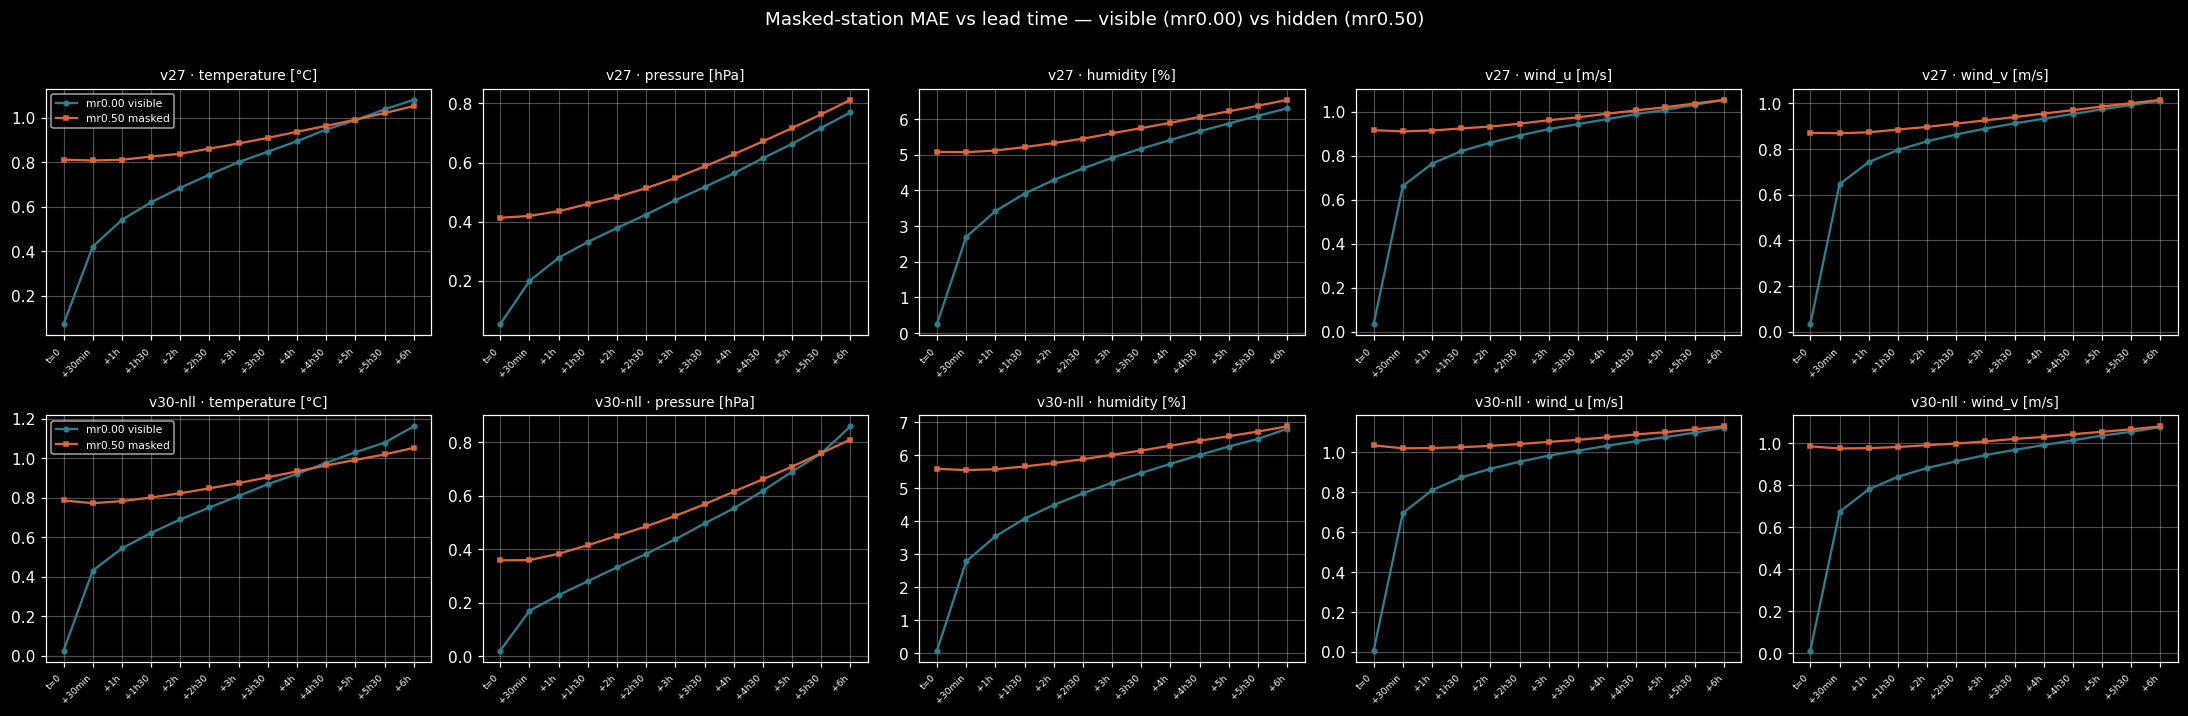

In [41]:
# ── Same comparison across lead time, per variable ───────────────────────────
runs2 = [r for r in RUNS if {"mr0.00","mr0.50"} <= set(RUNS[r])]
if runs2:
    fig, axes = plt.subplots(len(runs2), len(VARS), figsize=(4*len(VARS), 3.2*len(runs2)),
                             squeeze=False)
    for ri, run in enumerate(runs2):
        A5,C5 = AGG[(run,"mr0.50")]; A0,C0 = AGG[(run,"mr0.00")]
        for vi, v in enumerate(VARS):
            ax = axes[ri][vi]
            hid = M(A5, C5, "kv_m")[KSL,vi]
            vis = (M(A0, C0, "kv_m")[KSL,vi] if C0["kv_m"][:,vi].sum()
                   else M(A0, C0, "kv")[KSL,vi])
            ax.plot(range(NK), vis, "o-", color="#2E7D8C", lw=1.5, ms=3, label="mr0.00 visible")
            ax.plot(range(NK), hid, "s-", color="#D9663D", lw=1.5, ms=3, label="mr0.50 masked")
            ax.set_xticks(range(NK)); ax.set_xticklabels(LEAD_F, rotation=45, ha="right", fontsize=6)
            ax.set_title(f"{run} · {v} [{ulab(v)}]", fontsize=9); ax.grid(alpha=0.3)
            if vi==0: ax.legend(fontsize=7)
    fig.suptitle(f"Masked-station {METRIC} vs lead time — visible (mr0.00) vs hidden (mr0.50)"
                 + ("  ·  Δ=0 excluded" if K0 else ""), y=1.01)
    plt.tight_layout(); plt.show()

## 2. Model comparison vs persistence and climatology

Per-variable error against lead time, in whichever metric `METRIC` is set to.

Two reference baselines, and they fail in opposite directions:

- **persistence** — carry `y(t0)` forward. Near-perfect at short lead, degrades
  monotonically as the forecast walks away from the last observation.
- **climatology** — the observation 24 h earlier. Roughly flat in lead time, since
  it carries the diurnal cycle rather than the current state. It is the harder
  reference beyond a few hours, and the one that shows whether a model has learned
  anything more than "tomorrow looks like today".

A model that beats persistence at +6h but not climatology has not learned the
diurnal cycle; the reverse means it tracks the current state but not the daily
rhythm. The table reports skill against both, on MAE and MSE.


all runs compared at mr0.00


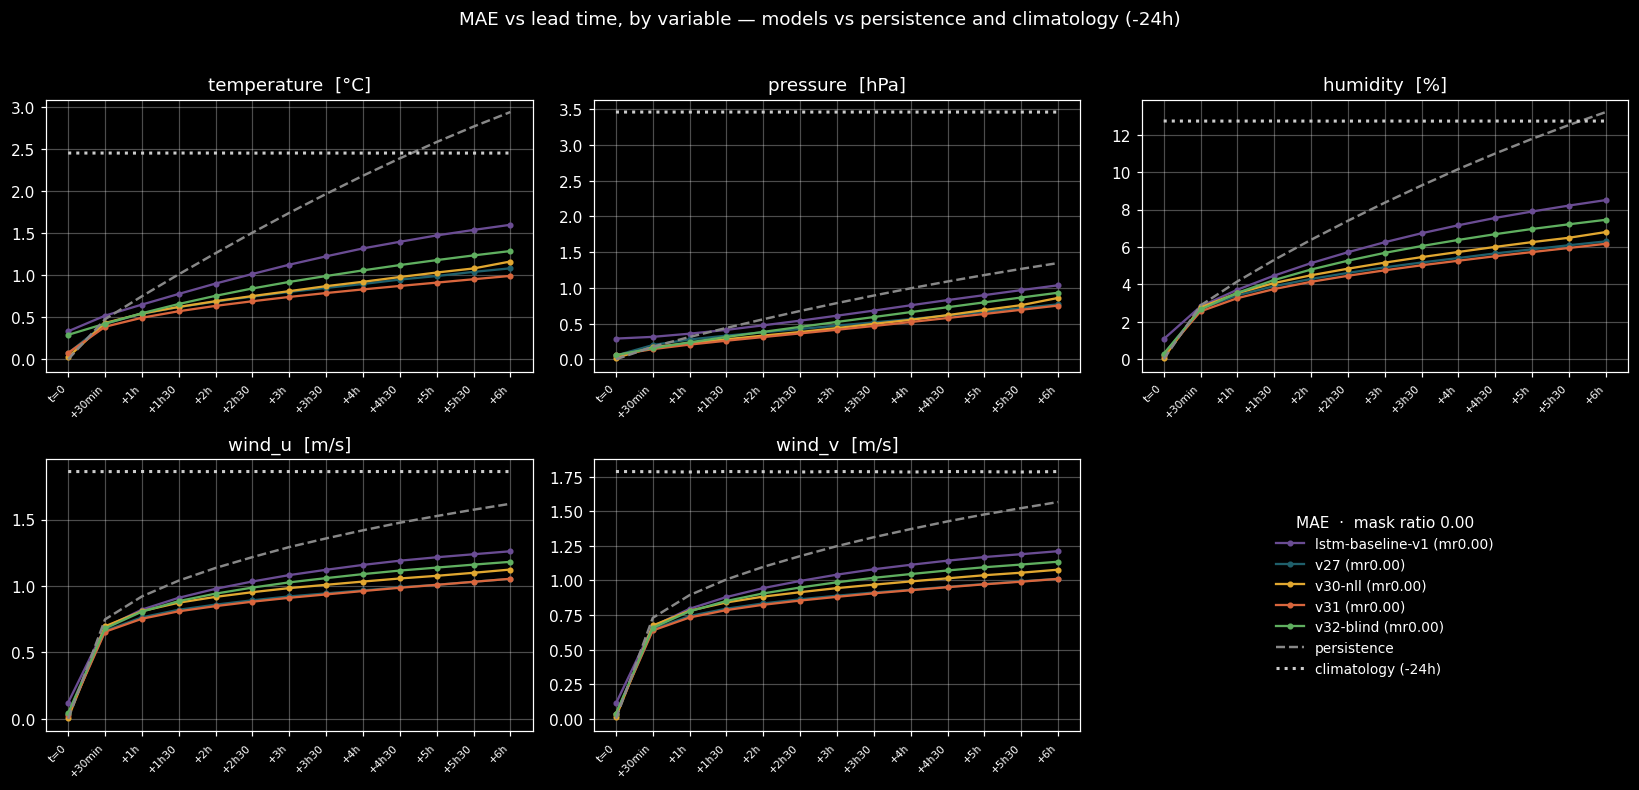

In [42]:
# ── Per-variable error vs lead time: models + persistence ───────────────────
# Plot follows METRIC (set in the config cell); the table below reports skill
# on BOTH MAE and MSE. Skill = 1 − model/persistence, so > 0 beats persistence.
# MSE-skill is the harsher test: it is dominated by the worst forecasts.
# Which mask ratio to show per run.
#
# This previously preferred mr0.50 wherever it existed, which silently put the
# transformers at mr0.50 and the LSTM at mr0.00 (the LSTM has no masking, so it
# only ever dumps mr0.00) — in the SAME comparison plot. Those are different
# tasks: at mr0.50 half the stations are hidden from the encoder. The headline
# comparison must hold the regime fixed.
#
# mr0.00 is the common regime: every run has it, and it is the one the LSTM and
# simple-MAE numbers were produced in.
COMPARE_MR = "mr0.00"           # ← "mr0.00" (comparable) | "mr0.50" (trained setting)

PREF = {}                       # run → mask ratio to display
for r in RUNS:
    PREF[r] = COMPARE_MR if COMPARE_MR in RUNS[r] else sorted(RUNS[r])[0]
_mixed = set(PREF.values())
if len(_mixed) > 1:
    print(f"⚠ runs are NOT all at the same mask ratio: "
          + ", ".join(f"{r}@{m}" for r, m in sorted(PREF.items()))
          + "\n  cross-model differences below are confounded with the regime.")
else:
    print(f"all runs compared at {COMPARE_MR}")

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (vi, v) in zip(axes.ravel(), enumerate(VARS)):
    for run, mr in PREF.items():
        A, C = AGG[(run, mr)]
        ax.plot(range(NK), M(A, C, "kv")[KSL, vi], "o-", ms=3, lw=1.5,
                color=COLOR(run), label=f"{run} ({mr})")
    # baselines — identical across runs, so take the first
    A, C = AGG[list(AGG)[0]]
    ax.plot(range(NK), M(A, C, "kv_p")[KSL, vi],
            "--", color=COLORS["persistence"], lw=1.6, label="persistence")
    ax.plot(range(NK), M(A, C, "kv_c")[KSL, vi],
            ":", color=COLORS["climatology"], lw=2.0, label="climatology (-24h)")
    ax.set_xticks(range(NK))
    ax.set_xticklabels(LEAD_F, rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{v}  [{ulab(v)}]"); ax.grid(alpha=0.3)
# One shared legend in the unused 6th panel. Per-axes legends sat on top of the
# curves in every panel, and at 6 entries they covered the +2h..+4h region —
# exactly where the models separate.
_lax = axes.ravel()[-1]; _lax.axis("off")
_h, _l = axes.ravel()[0].get_legend_handles_labels()
_lax.legend(_h, _l, loc="center", fontsize=9, frameon=False,
            title=f"{METRIC}  ·  mask ratio {COMPARE_MR[2:]}")
fig.suptitle(f"{METRIC} vs lead time, by variable — models vs persistence "
             f"and climatology (-24h)"
             + ("  ·  Δ=0 excluded" if K0 else ""), y=1.02)
plt.tight_layout(); plt.show()

# ── summary table: MAE and MSE side by side, with skill on each ─────────────
def _pool(A, C, key, sq, sl=slice(None), cnt_key=None):
    """Pool over horizons then reduce — never average per-horizon means."""
    num = A[key + ("_sq" if sq else "")][sl].sum()
    den = max(C[(cnt_key or key)][sl].sum(), 1)
    return num / den

rows = {}
Ap, Cp = AGG[list(AGG)[0]]
for run, mr in PREF.items():
    A, C = AGG[(run, mr)]
    for vi, v in enumerate(VARS):
        rec = {}
        for m, sq in (("MAE", False), ("MSE", True)):
            fc  = _pool(A,  C,  "kv",   sq, (slice(1, None), vi))
            per = _pool(Ap, Cp, "kv_p", sq, (slice(1, None), vi))
            cli = _pool(Ap, Cp, "kv_c", sq, (slice(1, None), vi))
            rec[f"{m} all"]         = _pool(A, C, "kv", sq, (slice(None), vi))
            rec[f"{m} Δ>0"]         = fc
            rec[f"persist {m} Δ>0"] = per
            rec[f"clim {m} Δ>0"]    = cli
            rec[f"{m} skill"]       = 1 - fc / per if per else np.nan
            rec[f"{m} skill_clim"]  = 1 - fc / cli if cli else np.nan
        rec["RMSE Δ>0"] = np.sqrt(rec["MSE Δ>0"])
        rows[(f"{run} ({mr})", v)] = rec

t = pd.DataFrame(rows).T; t.index.names = ["model", "variable"]
t = t[["MAE all","MAE Δ>0","persist MAE Δ>0","clim MAE Δ>0",
       "MAE skill","MAE skill_clim",
       "MSE all","MSE Δ>0","persist MSE Δ>0","clim MSE Δ>0",
       "MSE skill","MSE skill_clim","RMSE Δ>0"]]
display(t.style
        .format({c_: ("{:+.3f}" if "skill" in c_ else "{:.3f}") for c_ in t.columns})
        .background_gradient(cmap="RdYlGn", subset=["MAE skill","MAE skill_clim","MSE skill","MSE skill_clim"],
                             vmin=-0.6, vmax=0.6)
        .set_caption("skill = vs persistence, skill_clim = vs climatology(-24h); "
                     "> 0 beats that baseline. MSE is in squared units and "
                     "weights large errors quadratically — where MAE-skill and "
                     "MSE-skill disagree, the model's error distribution differs "
                     "in shape from persistence's, not just in scale."))

## 3. Terrain — valley vs mountainous stations

Stations are split by altitude and slope (`ALT_THRESH`, `SLOPE_THRESH` at the top).
Complex terrain is where spatial interpolation is hardest, so this is the clearest test
of whether the models cope with the Alps.

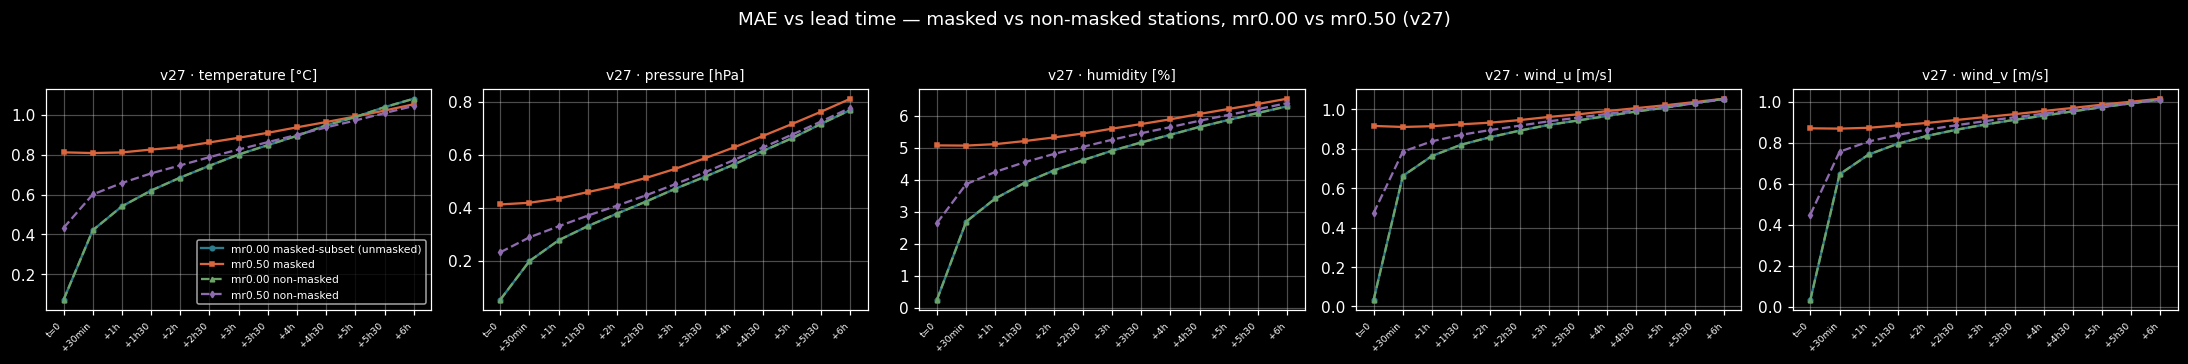

In [43]:
# ── Masked vs non-masked stations, mr0.00 vs mr0.50, single model ────────────
run = "v27"
A5, C5 = AGG[(run, "mr0.50")]
A0, C0 = AGG[(run, "mr0.00")]

fig, axes = plt.subplots(1, len(VARS), figsize=(4*len(VARS), 3.2), squeeze=False)
axes = axes[0]

for vi, v in enumerate(VARS):
    ax = axes[vi]

    # masked-subset stations: hidden under mr0.50 vs the same stations unmasked under mr0.00
    hid_mr50 = M(A5, C5, "kv_m")[KSL, vi]
    hid_mr00 = (M(A0, C0, "kv_m")[KSL, vi] if C0["kv_m"][:, vi].sum()
                else M(A0, C0, "kv")[KSL, vi])

    # non-masked stations: visible under both mr0.00 and mr0.50
    vis_mr50 = (M(A5, C5, "kv_nm")[KSL, vi] if "kv_nm" in C5 and C5["kv_nm"][:, vi].sum()
                else M(A5, C5, "kv")[KSL, vi])
    vis_mr00 = (M(A0, C0, "kv_nm")[KSL, vi] if "kv_nm" in C0 and C0["kv_nm"][:, vi].sum()
                else M(A0, C0, "kv")[KSL, vi])

    ax.plot(range(NK), hid_mr00, "o-",  color="#2E7D8C", lw=1.5, ms=3, label="mr0.00 masked-subset (unmasked)")
    ax.plot(range(NK), hid_mr50, "s-",  color="#D9663D", lw=1.5, ms=3, label="mr0.50 masked")
    ax.plot(range(NK), vis_mr00, "^--", color="#6BA368", lw=1.5, ms=3, label="mr0.00 non-masked")
    ax.plot(range(NK), vis_mr50, "d--", color="#8E6BAF", lw=1.5, ms=3, label="mr0.50 non-masked")

    ax.set_xticks(range(NK)); ax.set_xticklabels(LEAD_F, rotation=45, ha="right", fontsize=6)
    ax.set_title(f"{run} · {v} [{ulab(v)}]", fontsize=9); ax.grid(alpha=0.3)
    if vi == 0:
        ax.legend(fontsize=7)

fig.suptitle(f"{METRIC} vs lead time — masked vs non-masked stations, mr0.00 vs mr0.50 ({run})"
             + ("  ·  Δ=0 excluded" if K0 else ""), y=1.02)
plt.tight_layout(); plt.show()

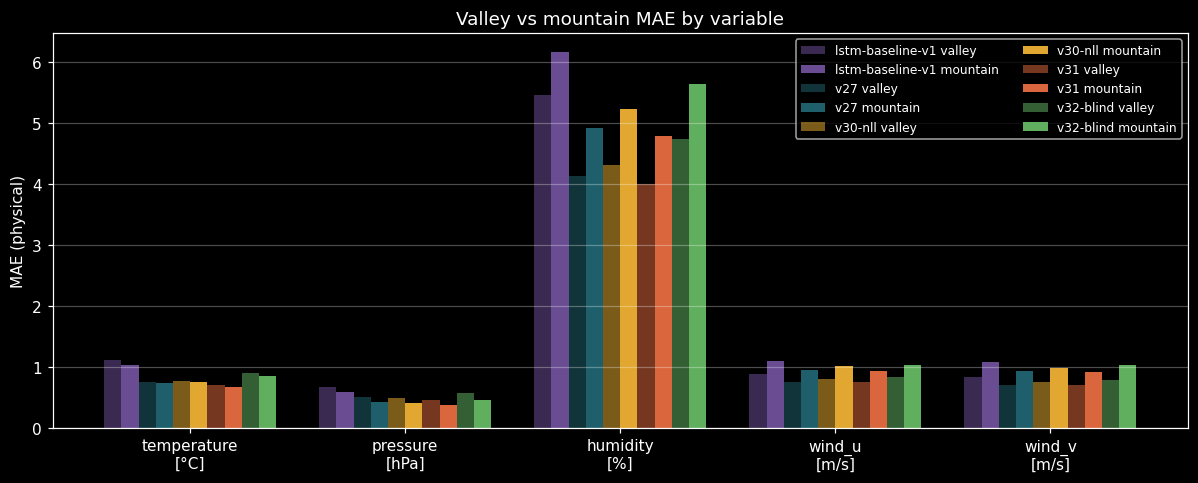

In [44]:
# ── Error by terrain class, per variable and model ───────────────────────────
rows = {}
for run, mr in PREF.items():
    A, C = AGG[(run, mr)]
    for vi, v in enumerate(VARS):
        for name, sel in [("valley", ~IS_MTN), ("mountain", IS_MTN)]:
            n   = max(C["sv"][sel, vi].sum(), 1)
            mae = A["sv"][sel, vi].sum() / n
            mse = A["sv_sq"][sel, vi].sum() / n
            rows[(f"{run} ({mr})", v, name)] = {
                "MAE": mae, "MSE": mse, "RMSE": np.sqrt(mse),
                "n_stations": int(sel.sum())}
t = pd.DataFrame(rows).T; t.index.names = ["model","variable","terrain"]

for m in ("MAE", "MSE"):
    piv = t[m].unstack("terrain").astype(float)
    piv["ratio mtn/valley"] = piv["mountain"] / piv["valley"]
    display(piv.style.format("{:.3f}")
            .background_gradient(cmap="OrRd", subset=["ratio mtn/valley"])
            .set_caption(f"{m} by terrain — ratio > 1 means the mountains are harder"
                         + ("  (squared units)" if m == "MSE" else "")))

x = np.arange(len(VARS)); nb_ = len(PREF); w = 0.8/max(nb_*2, 1)
fig, ax = plt.subplots(figsize=(11, 4.5))
for i, (run, mr) in enumerate(PREF.items()):
    A, C = AGG[(run, mr)]
    val, mtn = [], []
    for vi in range(len(VARS)):
        for sel, out in ((~IS_MTN, val), (IS_MTN, mtn)):
            n = max(C["sv"][sel, vi].sum(), 1)
            if METRIC == "MAE":   out.append(A["sv"][sel, vi].sum() / n)
            elif METRIC == "MSE": out.append(A["sv_sq"][sel, vi].sum() / n)
            else:                 out.append(np.sqrt(A["sv_sq"][sel, vi].sum() / n))
    ax.bar(x+(2*i-nb_+0.5)*w, val, w, color=COLOR(run), alpha=0.55,
           label=f"{run} valley")
    ax.bar(x+(2*i-nb_+1.5)*w, mtn, w, color=COLOR(run),
           label=f"{run} mountain")
ax.set_xticks(x); ax.set_xticklabels([f"{v}\n[{ulab(v)}]" for v in VARS])
ax.set_ylabel(f"{METRIC} (physical)")
ax.set_title(f"Valley vs mountain {METRIC} by variable")
ax.legend(fontsize=8, ncol=2); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Per-station performance by variable and season

Which stations the model handles well, and which it does not. Errors are normalised by
each station's own training σ (**nMAE**) so stations with different natural variability
are comparable — a raw MAE would simply rank the windiest sites worst.

In [45]:
# ── Per-station normalised error by variable, best / worst ──────────────────
# Normalised by the station's own training σ so stations are comparable:
#   nMAE, nRMSE  divide by σ      nMSE  divides by σ²   (units must match)
# Prefer the newest transformer run, then anything available.
_PREF_ORDER = ["v20", "v22", "v19", "v17", "v15", "simple-mae-v2",
               "masked-tf-v1", "simple-mae-v1",
               "lstm-baseline-v2", "lstm-baseline-v1", "v9"]
RUN_INSPECT = next((r for r in _PREF_ORDER if r in RUNS), list(RUNS)[0])
MR = PREF[RUN_INSPECT]
A, C = AGG[(RUN_INSPECT, MR)]

_n = np.maximum(C["sv"], 1)
_phys = {"MAE": A["sv"]/_n, "MSE": A["sv_sq"]/_n, "RMSE": np.sqrt(A["sv_sq"]/_n)}
_norm = {"MAE": _phys["MAE"]/STD, "MSE": _phys["MSE"]/STD**2, "RMSE": _phys["RMSE"]/STD}

nrm_tbl = pd.DataFrame(_norm[METRIC], index=STN, columns=VARS)
nrm_tbl["mean"] = nrm_tbl.mean(axis=1)
nrm_tbl["terrain"] = np.where(IS_MTN, "mountain", "valley")

print(f"{RUN_INSPECT} ({MR}) — per-station n{METRIC} "
      f"(error ÷ station σ{'²' if METRIC=='MSE' else ''})")
display(nrm_tbl.nsmallest(10, "mean").style.format({c_:"{:.3f}" for c_ in VARS+["mean"]})
        .set_caption(f"10 BEST stations (n{METRIC})"))
display(nrm_tbl.nlargest(10, "mean").style.format({c_:"{:.3f}" for c_ in VARS+["mean"]})
        .set_caption(f"10 WORST stations (n{METRIC})"))

# Do MAE and MSE agree on who the worst stations are? If not, those stations
# are hurt by occasional large errors rather than consistent mediocrity.
_wm = pd.DataFrame(_norm["MAE"], index=STN, columns=VARS).mean(axis=1).nlargest(15).index
_ws = pd.DataFrame(_norm["MSE"], index=STN, columns=VARS).mean(axis=1).nlargest(15).index
_only_mse = [s for s in _ws if s not in _wm]
print(f"\nWorst-15 by nMAE vs nMSE: {len(set(_wm) & set(_ws))}/15 in common.")
if _only_mse:
    print(f"  Bad on MSE only (large-error driven): {', '.join(_only_mse)}")

lstm-baseline-v1 (mr0.00) — per-station nMAE (error ÷ station σ)


,temperature,pressure,humidity,wind_u,wind_v,mean,terrain
LAC,0.127,0.000,0.329,0.000,0.000,0.091,valley
ILZ,0.128,0.093,0.262,0.000,0.000,0.096,valley
GRC,0.126,0.080,0.289,0.000,0.000,0.099,mountain
PSI,0.146,0.088,0.276,0.000,0.000,0.102,valley
LAE,0.139,0.098,0.330,0.000,0.000,0.113,valley
PRE,0.000,0.000,0.000,0.389,0.368,0.151,valley
STK,0.000,0.091,0.000,0.390,0.420,0.180,valley
AEG,0.000,0.000,0.000,0.561,0.484,0.209,valley
MTR,0.103,0.068,0.289,0.340,0.314,0.223,mountain
QUI,0.000,0.097,0.000,0.481,0.572,0.230,mountain


,temperature,pressure,humidity,wind_u,wind_v,mean,terrain
BIZ,0.145,0.093,0.284,0.627,0.704,0.371,valley
ARH,0.148,0.096,0.383,0.597,0.548,0.354,valley
INT,0.133,0.096,0.336,0.584,0.568,0.343,valley
GES,0.146,0.000,0.360,0.619,0.587,0.342,mountain
MOA,0.152,0.092,0.305,0.620,0.535,0.341,valley
CHZ,0.127,0.093,0.308,0.581,0.584,0.339,valley
MUB,0.133,0.089,0.296,0.402,0.748,0.334,valley
THU,0.146,0.092,0.318,0.526,0.584,0.333,valley
ARO,0.127,0.076,0.297,0.606,0.559,0.333,mountain
BOU,0.129,0.101,0.387,0.531,0.509,0.331,valley



Worst-15 by nMAE vs nMSE: 12/15 in common.
  Bad on MSE only (large-error driven): VLS, SCU, GIH


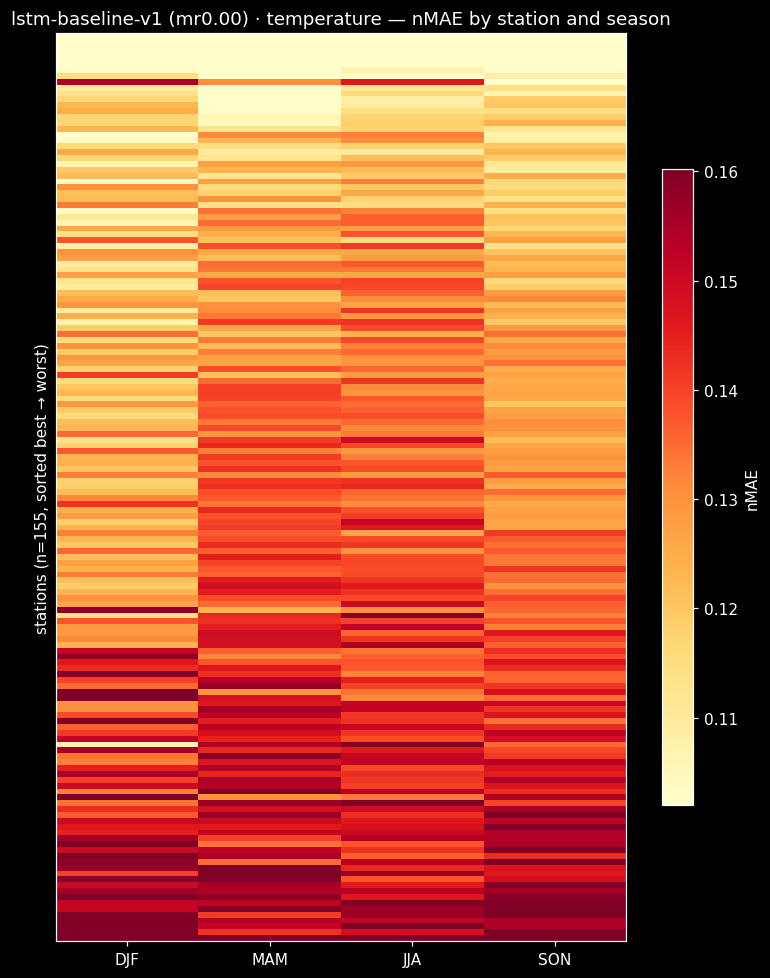

,DJF,MAM,JJA,SON
terrain,,,,
mountain,0.132,0.126,0.130,0.128
valley,0.122,0.137,0.134,0.127


,DJF,MAM,JJA,SON,worst season,terrain
ANT,0.196,0.142,0.148,0.171,DJF,mountain
SAM,0.179,0.134,0.138,0.154,DJF,mountain
BUF,0.177,0.130,0.133,0.154,DJF,mountain
BRL,0.177,0.168,0.173,0.187,SON,mountain
ROB,0.176,0.154,0.152,0.155,DJF,mountain
BIA,0.175,0.151,0.165,0.155,DJF,mountain
SBO,0.172,0.155,0.136,0.143,DJF,valley
BIV,0.165,0.141,0.156,0.171,SON,mountain
SIA,0.162,0.130,0.134,0.148,DJF,mountain
MAG,0.162,0.143,0.132,0.136,DJF,valley


In [46]:
# ── Station × season heatmap for one variable ────────────────────────────────
SEASON_VAR = "temperature"      # ← change variable
vi = VARS.index(SEASON_VAR)
_ns_n = np.maximum(C["svs"][:,vi,:], 1)
if METRIC == "MAE":
    ns = (A["svs"][:,vi,:] / _ns_n) / STD[:,vi:vi+1]
elif METRIC == "MSE":
    ns = (A["svs_sq"][:,vi,:] / _ns_n) / (STD[:,vi:vi+1]**2)
else:
    ns = np.sqrt(A["svs_sq"][:,vi,:] / _ns_n) / STD[:,vi:vi+1]   # (N,4) normalised
order = np.argsort(np.nanmean(ns, axis=1))

fig, ax = plt.subplots(figsize=(7, 9))
im = ax.imshow(ns[order], aspect="auto", cmap="YlOrRd",
               vmin=np.nanpercentile(ns,5), vmax=np.nanpercentile(ns,95))
ax.set_xticks(range(4)); ax.set_xticklabels(SEASONS)
ax.set_yticks([]); ax.set_ylabel(f"stations (n={N}, sorted best → worst)")
ax.set_title(f"{RUN_INSPECT} ({MR}) · {SEASON_VAR} — n{METRIC} by station and season")
plt.colorbar(im, ax=ax, label=f"n{METRIC}", shrink=0.7)
plt.tight_layout(); plt.show()

seas_tbl = pd.DataFrame(ns, index=STN, columns=SEASONS)
seas_tbl["worst season"] = seas_tbl[SEASONS].idxmax(axis=1)
seas_tbl["terrain"] = np.where(IS_MTN, "mountain", "valley")
display(seas_tbl.groupby("terrain")[SEASONS].mean().style.format("{:.3f}")
        .set_caption(f"{SEASON_VAR} n{METRIC} by season and terrain"))
display(seas_tbl.nlargest(12, SEASONS).style.format({s:"{:.3f}" for s in SEASONS})
        .set_caption(f"Stations struggling most on {SEASON_VAR}"))